In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
image_size= 256
batch_size= 32
channel=3

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!unzip -o -q "/content/drive/MyDrive/Plants.zip" -d "/content/dataset"

In [5]:
datast= tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/Plants", # Corrected path to include the 'Plants' directory
    shuffle= True,
    image_size= (image_size,image_size),
    batch_size= batch_size
)

Found 1904 files belonging to 3 classes.


In [6]:
class_names = datast.class_names # Corrected attribute name to 'class_names'
display(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
len(datast)

60

In [8]:
60*32

1920

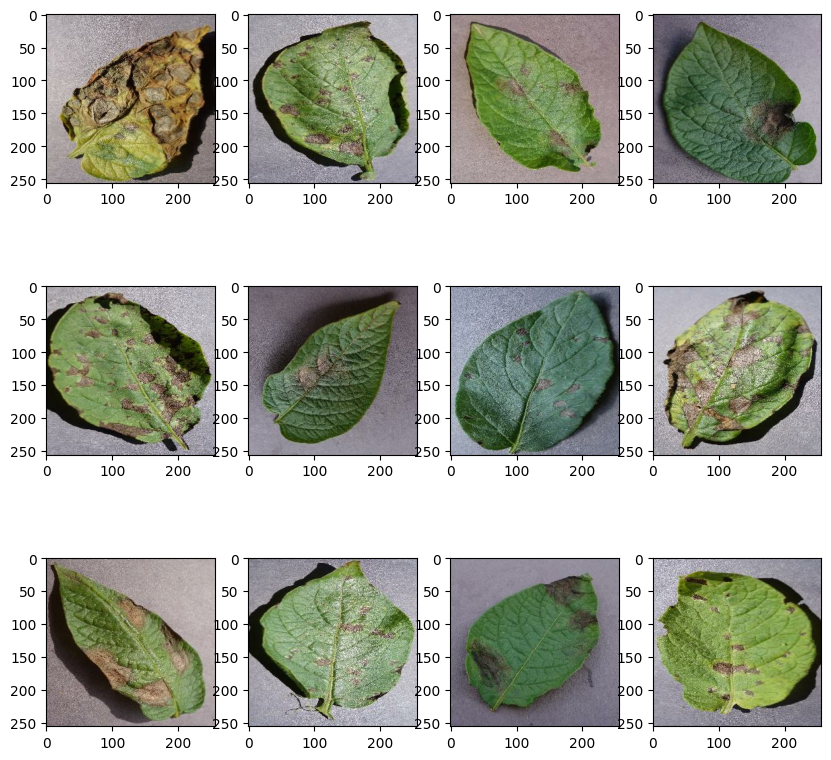

In [9]:
for image_batch, labels_batch in datast.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)
(256, 256, 3)


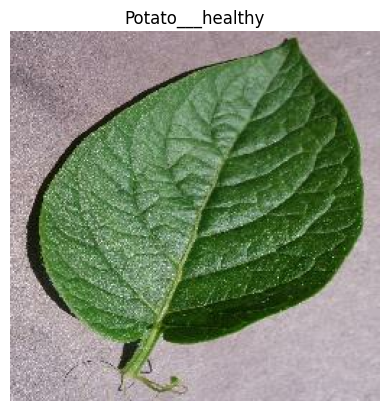

In [10]:
for image_batch, labels_batch in datast.take(1):
  for i in range(12):
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.axis("off")
    print(image_batch[i].shape)
    plt.title(class_names[labels_batch[i]])

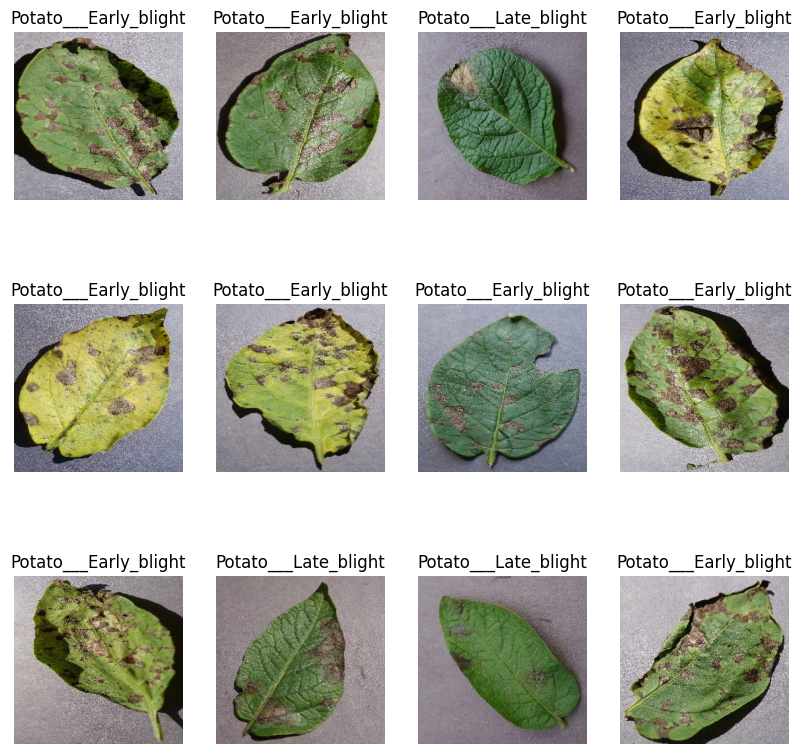

In [11]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in datast.take(1):
    for i in range(12):
      ax= plt.subplot(3, 4, i+1)
      plt.imshow(image_batch[i].numpy().astype("uint8"))
      plt.title(class_names[labels_batch[i]])
      plt.axis("off")

In [12]:
train_size= 0.8
len(datast)*train_size

48.0

In [13]:
train_ds= datast.take(48)
len(train_ds)

48

In [14]:
test_ds= datast.skip(48)
len(test_ds)

12

In [15]:
val_size= 0.1
len(datast)*val_size

6.0

In [16]:
val_ds= test_ds.take(6)
len(val_ds)

6

In [17]:
test_ds= test_ds.skip(6)
len(test_ds)

6

In [18]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size= len(ds)

    if shuffle:
        ds= ds.shuffle(shuffle_size, seed=12)

    train_size= int(train_split*ds_size)
    val_size= int(val_split*ds_size)

    train_ds= ds.take(train_size)

    val_ds= ds.skip(train_size).take(val_size)
    test_ds= ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [19]:
train_ds, val_ds, test_ds= get_dataset_partitions_tf(datast)

In [20]:
len(train_ds)

48

In [21]:
len(val_ds)

6

In [22]:
len(test_ds)

6

In [23]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [24]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(image_size, image_size),
    tf.keras.layers.Rescaling(1./255)
])

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

In [26]:
input_shape= (image_size, image_size, channel)
model= models.Sequential([
    tf.keras.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
histroy= model.fit(
    train_ds,
    batch_size=batch_size,
    validation_data=val_ds,
    verbose=1,
    epochs=15
)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.5138 - loss: 0.9321 - val_accuracy: 0.5208 - val_loss: 0.8709
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 228s 5s/step - accuracy: 0.6711 - loss: 0.7710 - val_accuracy: 0.7344 - val_loss: 0.6471
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 221s 5s/step - accuracy: 0.7625 - loss: 0.5275 - val_accuracy: 0.7604 - val_loss: 0.5400
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step - accuracy: 0.8651 - loss: 0.3477 - val_accuracy: 0.7760 - val_loss: 0.5626
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 232s 5s/step - accuracy: 0.8566 - loss: 0.3676 - val_accuracy: 0.8177 - val_loss: 0.3957
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.8829 - loss: 0.2843 - val_accuracy: 0.7917 - val_loss: 0.4526
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 276s 5s/step - accuracy: 0.8961 - loss: 0.2704 - val_accuracy: 0.8906 - val_loss: 0.2513
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.9336 - loss: 0.1891 - val_accuracy: 0.8698 - v

In [30]:
scores

NameError: name 'scores' is not defined

In [31]:
histroy

In [32]:
histroy.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [33]:
histroy.params

{'verbose': 1, 'epochs': 15, 'steps': 48}

In [34]:
scores= model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9427 - loss: 0.1856


In [35]:
acc= histroy.history['accuracy']
val_acc= histroy.history['val_accuracy']

loss= histroy.history['loss']
val_loss= histroy.history['val_loss']

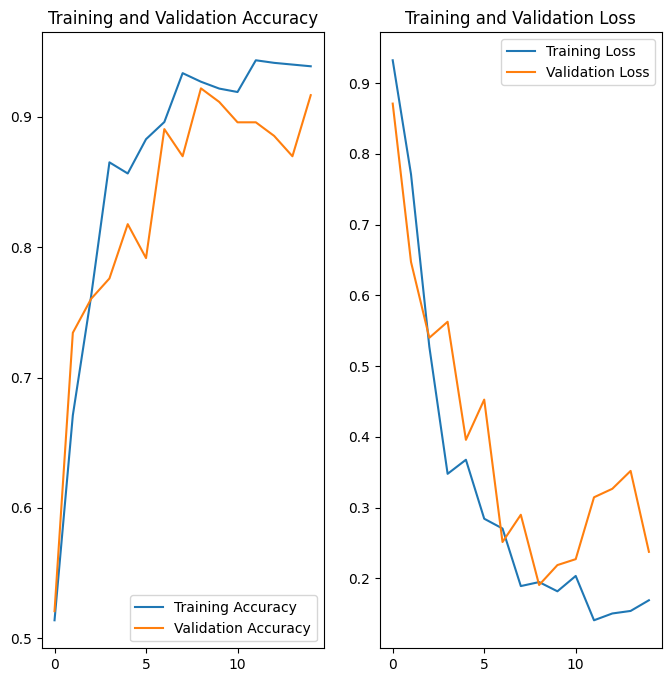

In [36]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(15), acc, label='Training Accuracy')
plt.plot(range(15), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(15), loss, label='Training Loss')
plt.plot(range(15), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
predicted label: Potato___Late_blight


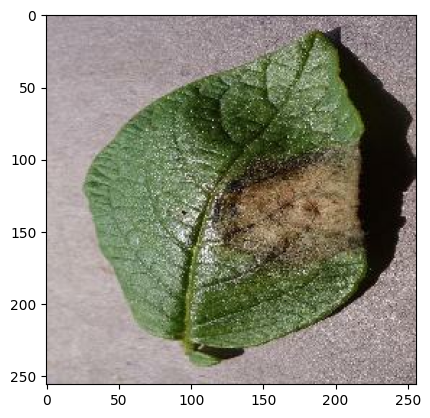

In [37]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
  first_image= images_batch[0].numpy().astype("uint8")
  first_label= labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:", class_names[first_label])

  batch_prediction= model.predict(images_batch)
  print("predicted label:", class_names[np.argmax(batch_prediction[0])])


In [38]:
def predict(model, img):
  img_array= tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array= tf.expand_dims(img_array, 0)

  predictions= model.predict(img_array)
  predicted_class= class_names[np.argmax(predictions[0])]
  confidence= round(100*(np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


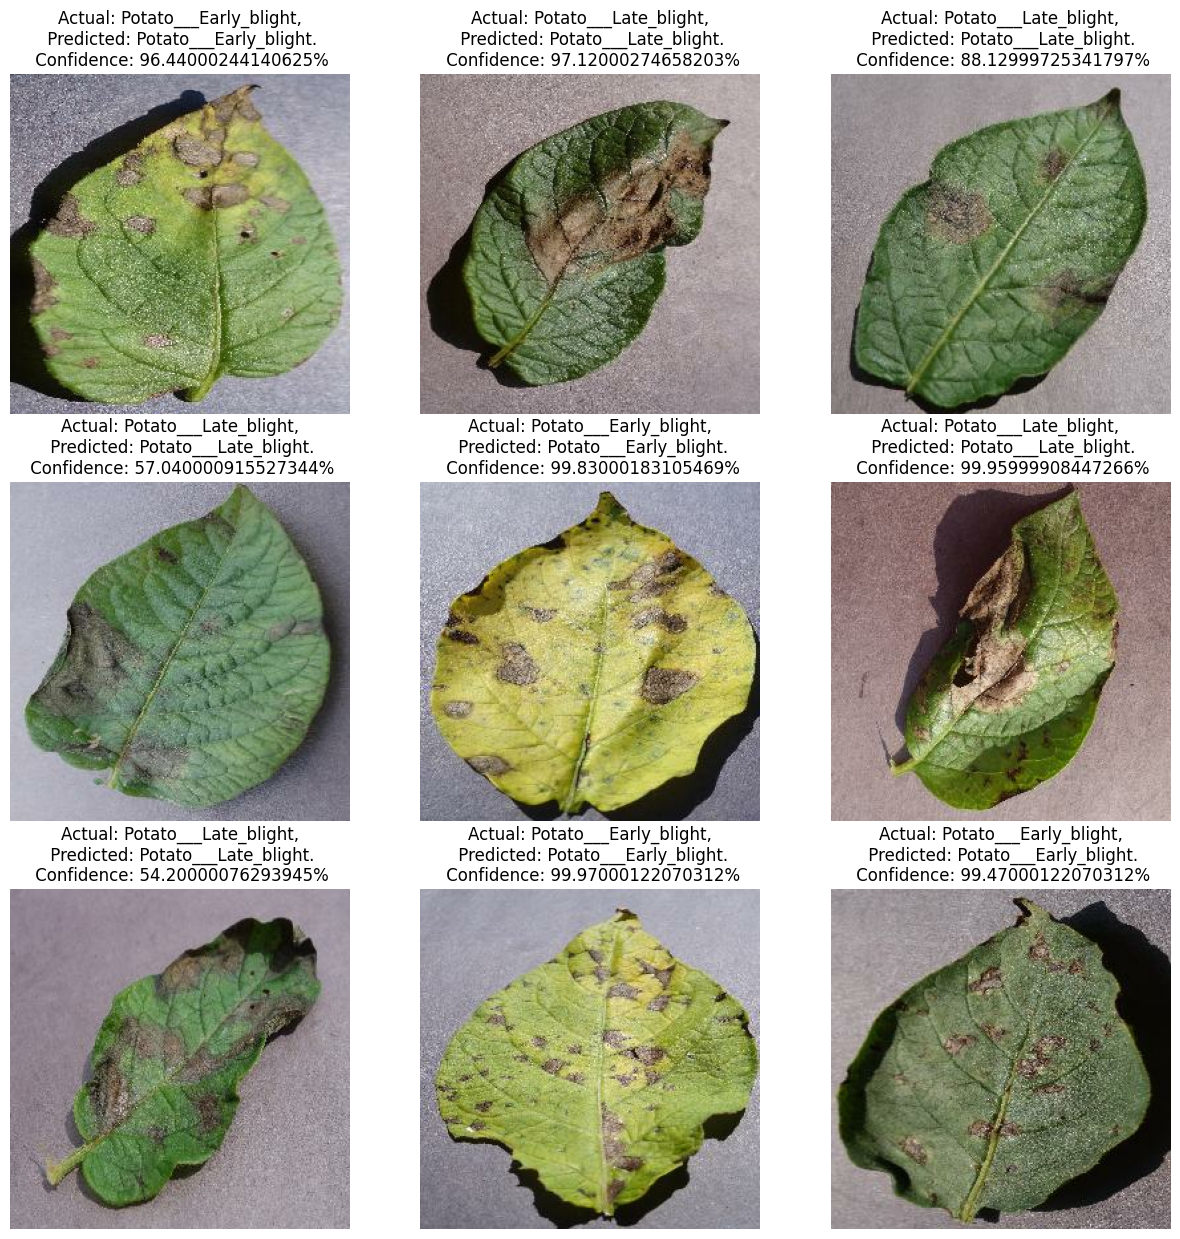

In [39]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax= plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence= predict(model, images[i].numpy())
    actual_class= class_names[labels[i]]

    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
    plt.axis('off')

In [40]:
import os
if not os.path.exists('../models'):
    os.makedirs('../models')
model_version= max([int(i) for i in os.listdir('../models') + [0]])+1
model.save(f"../models/{model_version}.keras")

In [41]:
model_version= 1
model.save(f'../models/{model_version}.keras')

In [42]:
import os

save_path = "/content/drive/MyDrive/PlantDiseaseAPI/models"
os.makedirs(save_path, exist_ok=True)

model.save(f"{save_path}/plant_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [43]:
!ls "/content/drive/MyDrive/PlantDiseaseAPI/models"

plant_model.keras


In [ ]:
%%writefile /content/main.py

In [ ]:
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
import numpy as np
from io import BytesIO
from PIL import Image
import tensorflow as tf
import uvicorn

app= FastAPI()
MODEL= tf.keras.models.load_model("/content/drive/MyDrive/PlantDiseaseAPI/models/1.keras")
CLASS_NAMES= ['Early_Blight', 'Late_Blight', 'Healthy']

@app.get('/ping')
async def ping():
  return "hello, I am alive"

def read_file_as_image(data) -> np.ndarray:
  image= np.array(Image.open(BytesIO(data)))
  return image

@app.post('/predict')
async def predict(
    file: UploadFile= File(...)
):
  image= read_file_as_image(await file.read())
  MODEL.predict(image)
  return


if __name__== '__main__':
  uvicorn.run(app, host='localhost', port=8000)

In [ ]:
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import numpy as np
from io import BytesIO
@@ -8,6 +9,18 @@

app = FastAPI()

origins = [
    "http://localhost",
    "http://localhost:3000",
]
app.add_middleware(
    CORSMiddleware,
    allow_origins=origins,
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

endpoint = "http://localhost:8501/v1/models/potatoes_model:predict"

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]